这次想做的纯净一点，那我可以只包含bao的数据，且去掉DV的数据，从而保证完全的模型无关的重构。
$$
D_A=\frac{D_M}{D_H}\frac{c}{H(z)(1+z)}
$$

In [43]:
import numpy as np
import pandas as pd
np.random.seed(42)

# 1. 读取数据
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)

# 2. 变量提取
mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
dm_rs, dh_rs = bao_val[mask_dm], bao_val[mask_dh]
z_exclude_dv = z_bao[mask_dh]

hz_exclude_dv = np.load('output/Hz_exclude_DV.npy')
hz_exclude_dv_cov = np.load('output/Hz_exclude_DV_cov.npy')

# 3. 计算 DA (Central Values)
c = 299792.458
da = dm_rs / dh_rs * c / (1 + z_exclude_dv) / hz_exclude_dv

# 4. 计算 DA 协方差 (Error Propagation)
# 提取 BAO 对应行列的索引
idx = np.concatenate([np.where(mask_dm)[0], np.where(mask_dh)[0]])
# 雅可比矩阵: J_bao=[DA/DM, -DA/DH], J_hz=[-DA/H]
j_bao = np.hstack([np.diag(da/dm_rs), np.diag(-da/dh_rs)]) #拼接
j_hz = np.diag(-da/hz_exclude_dv)
# 误差传播公式: C_DA = J_bao * C_BAO * J_bao.T + J_hz * C_Hz * J_hz.T
da_cov = j_bao @ bao_cov[np.ix_(idx, idx)] @ j_bao.T + j_hz @ hz_exclude_dv_cov @ j_hz.T

# 5. 计算 DL 及其协方差
scale = (1 + z_exclude_dv)**2
dl = da * scale
dl_cov = da_cov * np.outer(scale, scale)

print(f"DA: {da}\nDA_err: {np.sqrt(np.diag(da_cov))}")
print(f"DL: {dl}\nDL_err: {np.sqrt(np.diag(dl_cov))}")

DA: [1385.94203034 1547.34056428 1569.20505185 1673.5306419  1821.15051973
 2197.09006048]
DA_err: [105.23321064 110.1789488  105.27965569 115.52489698 150.37664905
 516.88448675]
DL: [ 3160.08642339  4503.43568254  5869.38553093  9015.37818267
 11236.96492124 24363.31197166]
DL_err: [ 239.94224358  320.66877903  393.78339184  622.33735657  927.86242105
 5731.68038509]


Running MCMC...


100%|██████████| 2000/2000 [00:05<00:00, 348.67it/s]


Removed no burn in


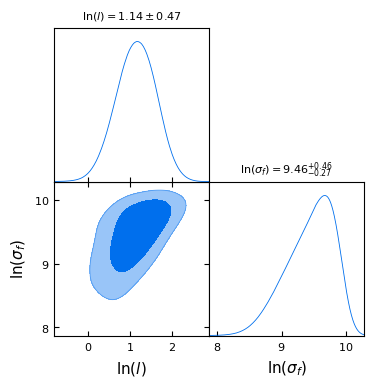

In [44]:
import utils
import matplotlib.pyplot as plt
import emcee
ndim = 2
KERNEL_NU = 2.5
N_WALKERS = 32
N_STEPS = 2000
BURN_IN = 500
p0 = np.random.normal([np.log(0.5), np.log(30)], 0.1, (N_WALKERS, ndim))
sampler = emcee.EnsembleSampler(
    N_WALKERS, ndim,
    utils.log_probability,
    args=(z_exclude_dv, dl, dl_cov, utils.matern_kernel),
    kwargs={"nu": KERNEL_NU}
)

print("Running MCMC...")
sampler.run_mcmc(p0, N_STEPS, progress=True)
theta_samples_union = sampler.get_chain(discard=BURN_IN, flat=True)

from getdist import MCSamples, plots
%matplotlib inline
names  = ["ln_l", "ln_sigma_f"]
labels = [r"\ln(l)", r"\ln(\sigma_f)"]
gdsamples = MCSamples(
    samples=theta_samples_union,
    names=names,
    labels=labels
)
gdsamples.updateSettings({
    'smooth_scale_1D': 0.5,
    'smooth_scale_2D': 0.5
})
g = plots.get_subplot_plotter()
g.triangle_plot(gdsamples, title_limit=1, filled=True)



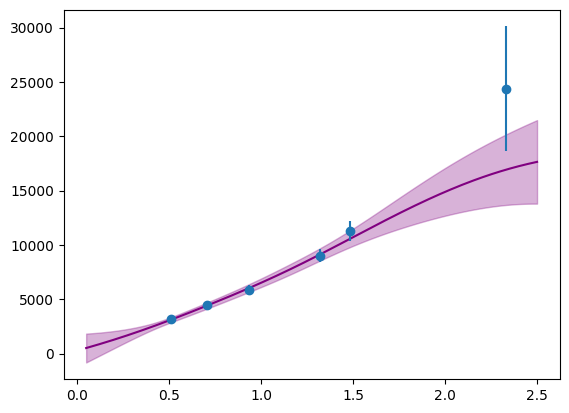

In [45]:
z_plot = np.linspace(0.05, 2.5, 200)
rec_bao_mean, rec_bao_cov = utils.predict_marginalized(z_exclude_dv, dl, dl_cov, z_plot, utils.matern_kernel, np.exp(theta_samples_union), nu = KERNEL_NU)
rec_bao_std = np.sqrt(np.diag(rec_bao_cov))


plt.plot(z_plot, rec_bao_mean, color='purple', label=r'Reconstructed $D_A(z)$ from BAO')
plt.fill_between(z_plot, 
                 rec_bao_mean - rec_bao_std, 
                 rec_bao_mean + rec_bao_std, 
                 color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')

plt.errorbar(z_exclude_dv, dl, np.sqrt(np.diag(dl_cov)), fmt='o')
plt.show()

In [46]:
theta_mB_samples = np.load('output/theta_samples_52.npy')
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

mB_baomatch_mean, mB_baomatch_cov = utils.predict_marginalized(
    np.log10(z_sn), mB_obs, mB_cov, np.log10(z_exclude_dv), 
    utils.matern_kernel, 
    theta_mB_samples, 
    nu=KERNEL_NU
)
# np.save('output/mB_baomatch_mean.npy', mB_baomatch_mean)
# np.save('output/mB_baomatch_cov.npy', mB_baomatch_cov)
mB_baomatch_std = np.sqrt(np.diag(mB_baomatch_cov))

In [47]:
n_MC = 1000
MB = -19.396 #-19.384
MB_err = 0.016 #0.052

#模板，记住
mB_baomatch_samples = np.random.multivariate_normal(mB_baomatch_mean, mB_baomatch_cov, size=n_MC)
MB_samples = np.random.normal(MB, MB_err, n_MC)

DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
DL_sn_mean = np.mean(DL_sn_samples, axis=0)#important 求均值 axis=0是让每一列取均值
DL_sn_cov = np.cov(DL_sn_samples, rowvar=False)#important 求协方差，让列成为变量而不是行

DL_bao_samples = np.random.multivariate_normal(dl, dl_cov, size=n_MC)
DL_bao_mean = np.mean(DL_bao_samples, axis=0)
DL_bao_cov = np.cov(DL_bao_samples, rowvar=False)

eta_samples = DL_sn_samples / DL_bao_samples
eta_mean = np.mean(eta_samples, axis=0)
eta_cov = np.cov(eta_samples, rowvar=False)

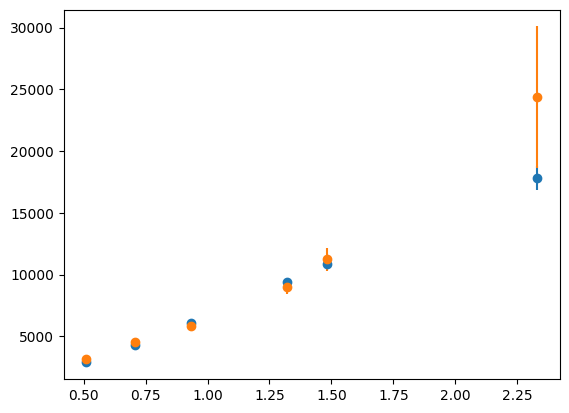

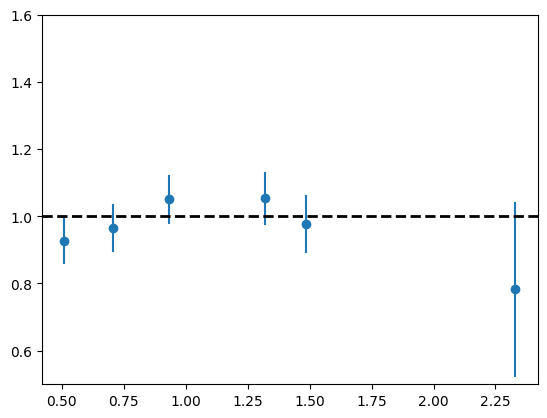

chi2: 3.04, p-value: 0.8038
Number of BAO points: 13


In [48]:
plt.errorbar(z_exclude_dv, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)), fmt='o')
plt.errorbar(z_exclude_dv, dl, np.sqrt(np.diag(dl_cov)), fmt='o')
plt.show()
plt.errorbar(z_exclude_dv, eta_mean, np.sqrt(np.diag(eta_cov)), fmt='o')
plt.axhline(1.0, color='black', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')
plt.ylim(0.5, 1.6)
plt.show()
chi2_val, p_val = utils.eta_chi2(eta_mean, np.sqrt(np.diag(eta_cov)))
print(f"chi2: {chi2_val:.2f}, p-value: {p_val:.4f}")
print(f"Number of BAO points: {len(z_bao)}")

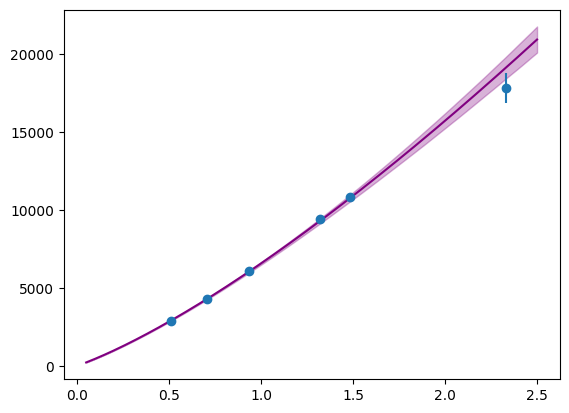

In [49]:
theta_mB_samples = np.load("output/theta_samples_52.npy")
theta_mB_samples = np.exp(theta_mB_samples) 
mB_pred_mean, mB_pred_cov = utils.predict_marginalized(
    np.log10(z_sn), mB_obs, mB_cov, np.log10(z_plot), 
    utils.matern_kernel, 
    theta_mB_samples, 
    nu=KERNEL_NU 
)
mB_samples = np.random.multivariate_normal(mB_pred_mean, mB_pred_cov, size=n_MC)
DL_samples = 10**((mB_samples - MB_samples[:, np.newaxis] - 25) / 5)
rec_sn_mean = np.mean(DL_samples, axis=0)
rec_sn_std = 0.5 * (np.percentile(DL_samples, 84, axis=0) - np.percentile(DL_samples, 16, axis=0))
plt.plot(z_plot, rec_sn_mean, color='purple', label=r'Reconstructed $D_L(z)$ from SN')
plt.fill_between(z_plot, 
                 rec_sn_mean - rec_sn_std, 
                 rec_sn_mean + rec_sn_std, 
                 color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')
plt.errorbar(z_exclude_dv, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)), fmt='o')
plt.show()

In [50]:
rec_eta = rec_sn_mean/rec_bao_mean
rec_eta_std = rec_eta * np.sqrt((rec_sn_std/rec_sn_mean)**2+(rec_bao_std/rec_bao_mean)**2)

In [51]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
DL = cosmo.luminosity_distance(z_plot).value 

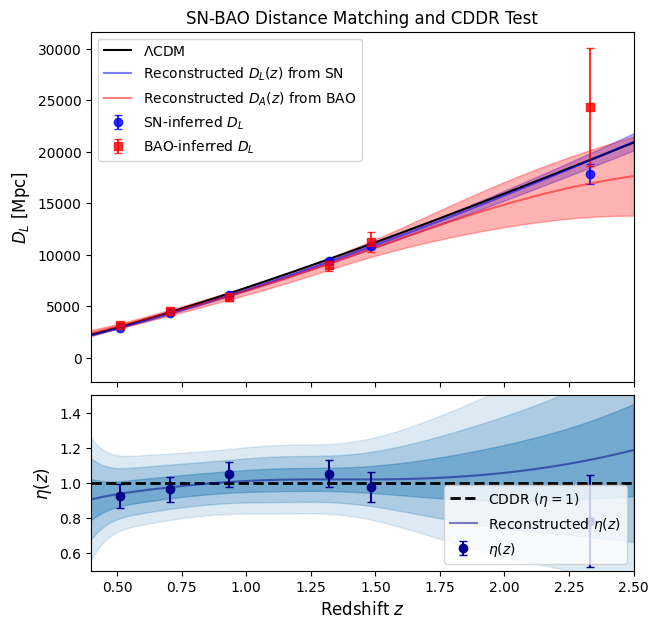

In [52]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05}
)

ax1.plot(z_plot, DL, color='black', label=r'$\Lambda$CDM')

ax1.errorbar(
    z_exclude_dv, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)),
    fmt='o', label=r'SN-inferred $D_L$', capsize=3, color='blue', alpha=0.8
)

ax1.errorbar(
    z_exclude_dv, dl, np.sqrt(np.diag(dl_cov)),
    fmt='s', label=r'BAO-inferred $D_L$', capsize=3, color='red', alpha=0.8
)

ax1.plot(z_plot, rec_sn_mean, color='blue', alpha=0.5, label=r'Reconstructed $D_L(z)$ from SN')
ax1.fill_between(z_plot, 
                 rec_sn_mean - rec_sn_std, 
                 rec_sn_mean + rec_sn_std, 
                 color='blue', alpha=0.3)

ax1.plot(z_plot, rec_bao_mean, color='red', alpha=0.5, label=r'Reconstructed $D_A(z)$ from BAO')
ax1.fill_between(z_plot, 
                 rec_bao_mean - rec_bao_std, 
                 rec_bao_mean + rec_bao_std, 
                 color='red', alpha=0.3)

ax1.set_ylabel(r'$D_L\ \mathrm{[Mpc]}$', fontsize=12)
ax1.legend()
ax1.set_title("SN-BAO Distance Matching and CDDR Test")

ax2.errorbar(
    z_exclude_dv, eta_mean, np.sqrt(np.diag(eta_cov)),
    fmt='o', capsize=3, label=r'$\eta(z)$',color='darkblue'
)

ax2.axhline(
    1.0, color='black', linestyle='--', linewidth=2,
    label=r'CDDR ($\eta = 1$)'
)

ax2.plot(z_plot, rec_eta, alpha=0.5, label=r'Reconstructed $\eta(z)$',color ='darkblue')
for sigma, alpha, label in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
        ax2.fill_between(z_plot,
                (rec_eta - sigma * rec_eta_std),
                (rec_eta + sigma * rec_eta_std),
                color='#1f77b4', alpha=alpha)

ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel(r'Redshift $z$', fontsize=12)
ax2.set_ylabel(r'$\eta(z)$', fontsize=12)
ax2.legend()

plt.xlim(0.4, 2.5)
plt.show()


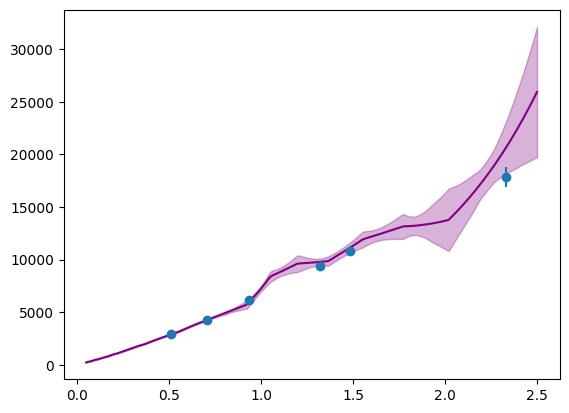

In [53]:
mB_cp_chain = np.load('output/mB_cp_chain.npy')
z_cp, _, _ = np.loadtxt('output/mB_cp_summary.txt', unpack=True)
chain_indices = np.random.choice(len(mB_cp_chain), n_MC, replace=False) # 从链里面抽nMC个序号值 36维度的array

DL_samples_CPI = np.zeros((n_MC, len(z_plot)))
for i, chain_idx in enumerate(chain_indices):
    DL_samples_CPI[i] = utils.compute_DL_SN(z_plot, mB_cp_chain[chain_idx], MB_samples[i], z_cp) # 这里的的函数用控制点差值计算出了DL

DL_sn_samples_CPI = np.zeros((n_MC, len(z_exclude_dv)))
for i, chain_idx in enumerate(chain_indices):
    DL_sn_samples_CPI[i] = utils.compute_DL_SN(z_exclude_dv, mB_cp_chain[chain_idx], MB_samples[i], z_cp) # 这里的的函数用控制点差值计算出了DL

eta_samples = DL_sn_samples_CPI / DL_bao_samples
eta_mean = np.mean(eta_samples, axis=0)
eta_cov = np.cov(eta_samples, rowvar=False)

rec_sn_mean = np.mean(DL_samples_CPI, axis=0)
rec_sn_std = 0.5 * (np.percentile(DL_samples_CPI, 84, axis=0) - np.percentile(DL_samples_CPI, 16, axis=0))
plt.plot(z_plot, rec_sn_mean, color='purple', label=r'Reconstructed $D_L(z)$ from SN')
plt.fill_between(z_plot, 
                 rec_sn_mean - rec_sn_std, 
                 rec_sn_mean + rec_sn_std, 
                 color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')
plt.errorbar(z_exclude_dv, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)), fmt='o')
plt.show()

In [54]:
rec_eta = rec_sn_mean/rec_bao_mean
rec_eta_std = rec_eta * np.sqrt((rec_sn_std/rec_sn_mean)**2+(rec_bao_std/rec_bao_mean)**2)

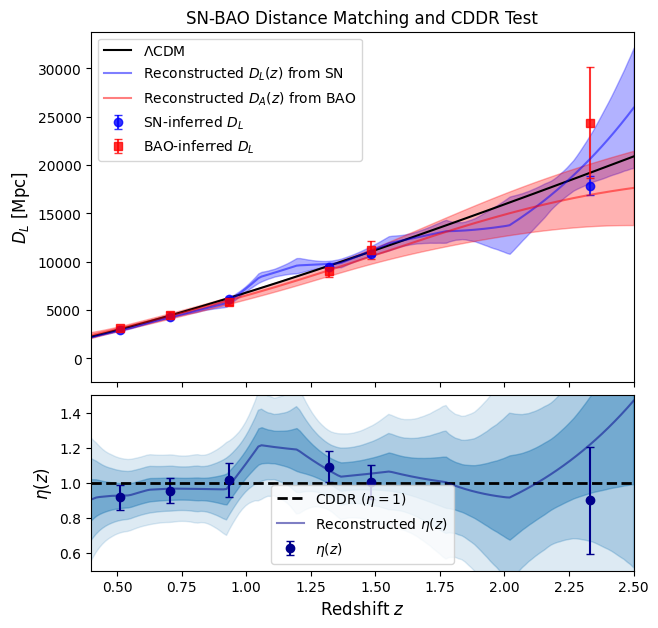

In [55]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05}
)

ax1.plot(z_plot, DL, color='black', label=r'$\Lambda$CDM')

ax1.errorbar(
    z_exclude_dv, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)),
    fmt='o', label=r'SN-inferred $D_L$', capsize=3, color='blue', alpha=0.8
)

ax1.errorbar(
    z_exclude_dv, dl, np.sqrt(np.diag(dl_cov)),
    fmt='s', label=r'BAO-inferred $D_L$', capsize=3, color='red', alpha=0.8
)

ax1.plot(z_plot, rec_sn_mean, color='blue', alpha=0.5, label=r'Reconstructed $D_L(z)$ from SN')
ax1.fill_between(z_plot, 
                 rec_sn_mean - rec_sn_std, 
                 rec_sn_mean + rec_sn_std, 
                 color='blue', alpha=0.3)

ax1.plot(z_plot, rec_bao_mean, color='red', alpha=0.5, label=r'Reconstructed $D_A(z)$ from BAO')
ax1.fill_between(z_plot, 
                 rec_bao_mean - rec_bao_std, 
                 rec_bao_mean + rec_bao_std, 
                 color='red', alpha=0.3)

ax1.set_ylabel(r'$D_L\ \mathrm{[Mpc]}$', fontsize=12)
ax1.legend()
ax1.set_title("SN-BAO Distance Matching and CDDR Test")

ax2.errorbar(
    z_exclude_dv, eta_mean, np.sqrt(np.diag(eta_cov)),
    fmt='o', capsize=3, label=r'$\eta(z)$',color='darkblue'
)

ax2.axhline(
    1.0, color='black', linestyle='--', linewidth=2,
    label=r'CDDR ($\eta = 1$)'
)

ax2.plot(z_plot, rec_eta, alpha=0.5, label=r'Reconstructed $\eta(z)$',color ='darkblue')
for sigma, alpha, label in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
        ax2.fill_between(z_plot,
                (rec_eta - sigma * rec_eta_std),
                (rec_eta + sigma * rec_eta_std),
                color='#1f77b4', alpha=alpha)

ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel(r'Redshift $z$', fontsize=12)
ax2.set_ylabel(r'$\eta(z)$', fontsize=12)
ax2.legend()

plt.xlim(0.4, 2.5)
plt.show()


Best MB: -19.4242 +/- 0.1111
Min Chi2: 2.80


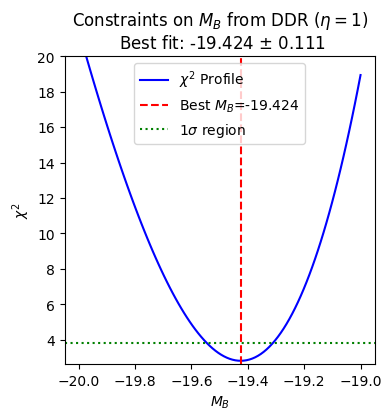

In [56]:
# 1. 准备网格和预生成样本 (避免循环内重复生成随机数，提高速度和稳定性)
n_MC = 1000  # 稍微增加样本数以保证协方差稳定
mb_grid = np.linspace(-20, -19, 100) # 根据你的先验范围调整
chi2_list = []

# 预生成观测数据的样本 (固定随机性)
# 注意：这里只生成 mB_obs 和 DL_bao 的样本，MB在循环中作为待定参数，不加噪声
mB_obs_samples = np.random.multivariate_normal(mB_baomatch_mean, mB_baomatch_cov, size=n_MC)
DL_bao_samples = np.random.multivariate_normal(dl, dl_cov, size=n_MC)

# 2. 网格搜索循环
for mb_val in mb_grid:
    # 计算当前 MB 下的 SN 距离 (mb_val 是常数)
    DL_sn_samples = 10**((mB_obs_samples - mb_val - 25) / 5)
    
    # 计算 Eta
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    
    # 计算 Chi2 (Eta 理论值为 1)
    diff = eta_mean - 1.0
    cinv = np.linalg.inv(eta_cov)
    chi2 = diff.T @ cinv @ diff
        
    chi2_list.append(chi2)

# 3. 寻找最优解
chi2_arr = np.array(chi2_list)
min_idx = np.argmin(chi2_arr)
best_mb = mb_grid[min_idx]
min_chi2 = chi2_arr[min_idx]

# 4. 估算 1-sigma 误差 (Chi2 = min_chi2 + 1 的范围)
# 使用插值或是简单的布尔索引
delta_chi2 = chi2_arr - min_chi2
sigma_region = mb_grid[delta_chi2 <= 1.0]
mb_err_low = best_mb - sigma_region[0]
mb_err_high = sigma_region[-1] - best_mb
best_mb_err = (mb_err_low + mb_err_high) / 2 # 取平均

print(f"Best MB: {best_mb:.4f} +/- {best_mb_err:.4f}")
print(f"Min Chi2: {min_chi2:.2f}")

# 5. 绘图
plt.figure(figsize=(4, 4))
plt.plot(mb_grid, chi2_arr, 'b-', label=r'$\chi^2$ Profile')
plt.axvline(best_mb, color='r', linestyle='--', label=f'Best $M_B$={best_mb:.3f}')
plt.axhline(min_chi2 + 1, color='g', linestyle=':', label=r'$1\sigma$ region')
plt.xlabel(r'$M_B$')
plt.ylabel(r'$\chi^2$')
plt.ylim(min(chi2_arr)-0.2,20)
plt.legend()
plt.title(f'Constraints on $M_B$ from DDR ($\eta=1$)\n Best fit: {best_mb:.3f} $\pm$ {best_mb_err:.3f}')
plt.show()

# # 6. 使用最佳 MB 绘制最终的 Eta 图 (可选)
# # 重新计算最佳情况用于展示
# best_DL_sn_samples = 10**((mB_obs_samples - best_mb - 25) / 5)
# best_eta_samples = best_DL_sn_samples / DL_bao_samples
# best_eta_mean = np.mean(best_eta_samples, axis=0)
# best_eta_cov = np.cov(best_eta_samples, rowvar=False)

# plt.errorbar(z_exclude_dv, best_eta_mean, np.sqrt(np.diag(best_eta_cov)), fmt='o', color='purple', label=f'Best fit $\eta$ ($M_B$={best_mb:.2f})')
# plt.axhline(1.0, color='black', linestyle='--', linewidth=2)
# plt.xlabel('z')
# plt.ylabel(r'$\eta(z)$')
# plt.legend()
# plt.show()

In [57]:
#这是通过最后得到的数据点进行的重构，供参考
# p0 = np.random.normal([np.log(0.5), np.log(30)], 0.1, (N_WALKERS, ndim))
# sampler = emcee.EnsembleSampler(
#     N_WALKERS, ndim,
#     utils.log_probability,
#     args=(z_exclude_dv, DL_sn_mean, DL_sn_cov, utils.matern_kernel),
#     kwargs={"nu": KERNEL_NU}
# )
# sampler.run_mcmc(p0, N_STEPS, progress=True)
# theta_sn_samples = sampler.get_chain(discard=BURN_IN, flat=True)
# rec_sn_mean, rec_sn_cov = utils.predict_marginalized(z_exclude_dv, DL_sn_mean, DL_sn_cov, z_plot, utils.matern_kernel, np.exp(theta_sn_samples), nu = KERNEL_NU)
# rec_sn_std = np.sqrt(np.diag(rec_sn_cov))
# plt.plot(z_plot, rec_sn_mean, color='purple', label=r'Reconstructed $D_L(z)$ from SN')
# plt.fill_between(z_plot, 
#                  rec_sn_mean - rec_sn_std, 
#                  rec_sn_mean + rec_sn_std, 
#                  color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')
# plt.errorbar(z_exclude_dv, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)), fmt='o')
# plt.show()